# Comparaison de tous les résultats Baseline

Compare les scores (accuracy) des trois prompts baseline — **NLI**, **Clinical Matching**, **CoT** — en **Global**, **POL** et **MEDICAL**. Sauvegarde les graphiques dans `graphes/` et exporte les listes d'indices où **tous** les modèles baseline se trompent (POL et MEDICAL) dans des CSV.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

RESULTS_DIR = "."
GRAPHS_DIR = os.path.join(RESULTS_DIR, "graphes")
os.makedirs(GRAPHS_DIR, exist_ok=True)

df_nli = pd.read_csv(os.path.join(RESULTS_DIR, "Prompt_NLI", "eval_nli_combined_baseline.csv"))
df_cm = pd.read_csv(os.path.join(RESULTS_DIR, "Prompt_clinical_matching", "eval_clinical_matching_combined_baseline.csv"))
df_cot = pd.read_csv(os.path.join(RESULTS_DIR, "Prompt_cot", "eval_cot_combined_baseline.csv"))

df = df_nli[["index", "statement_type", "gold"]].copy()
df["correct_nli"] = df_nli["is_correct"]
df["correct_cm"] = df_cm["is_correct"]
df["correct_cot"] = df_cot["is_correct"]

print("Lignes chargées:", len(df))
df.head(10)

Lignes chargées: 3156


,index,statement_type,gold,correct_nli,correct_cm,correct_cot
0,0,pol,Entailment,False,False,True
1,1,pol,Contradiction,False,False,False
2,2,pol,Entailment,True,True,True
3,3,pol,Contradiction,True,True,True
4,4,pol,Contradiction,True,True,True
5,5,pol,Entailment,False,True,True
6,6,pol,Entailment,False,False,True
7,7,pol,Entailment,False,True,True
8,8,pol,Contradiction,True,True,False
9,9,pol,Contradiction,True,True,True


## Scores (accuracy) par prompt — Global, POL, MEDICAL

In [2]:
scores = pd.DataFrame({
    "NLI": [
        df["correct_nli"].mean(),
        df[df["statement_type"] == "pol"]["correct_nli"].mean(),
        df[df["statement_type"] == "medical"]["correct_nli"].mean(),
    ],
    "Clinical Matching": [
        df["correct_cm"].mean(),
        df[df["statement_type"] == "pol"]["correct_cm"].mean(),
        df[df["statement_type"] == "medical"]["correct_cm"].mean(),
    ],
    "CoT": [
        df["correct_cot"].mean(),
        df[df["statement_type"] == "pol"]["correct_cot"].mean(),
        df[df["statement_type"] == "medical"]["correct_cot"].mean(),
    ],
}, index=["Global", "POL", "MEDICAL"])

print("Accuracy (0–1) par prompt et par split:")
display(scores.round(4))

Accuracy (0–1) par prompt et par split:


,NLI,Clinical Matching,CoT
Global,0.557,0.6616,0.7224
POL,0.538,0.6496,0.7047
MEDICAL,0.576,0.6736,0.7402


## Graphique — Comparaison des scores

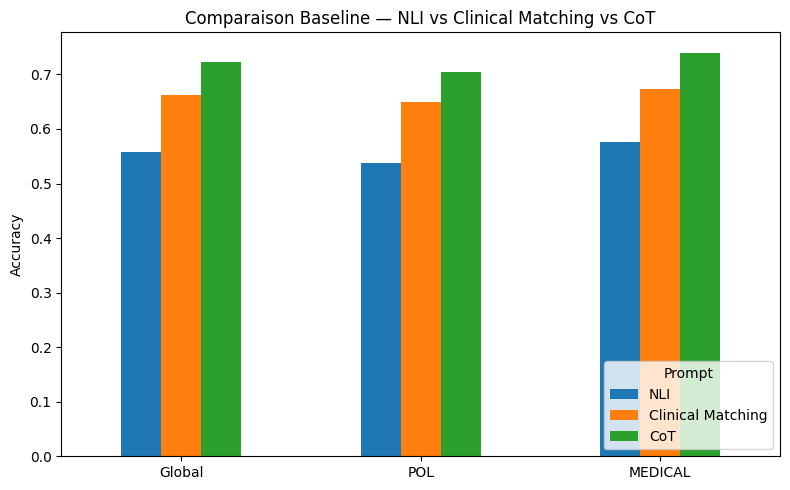

In [3]:
scores.plot(kind="bar", ylabel="Accuracy", title="Comparaison Baseline — NLI vs Clinical Matching vs CoT", rot=0, figsize=(8, 5))
plt.legend(loc="lower right", title="Prompt")
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "compare_all_baseline_accuracy.png"), dpi=150, bbox_inches="tight")
plt.show()

## Indices où tous les baselines se trompent (POL et MEDICAL)

Export des listes d'indices pour lesquels **NLI**, **Clinical Matching** et **CoT** (baseline) sont tous en erreur.

In [4]:
wrong_nli = ~df["correct_nli"]
wrong_cm = ~df["correct_cm"]
wrong_cot = ~df["correct_cot"]
all_wrong = wrong_nli & wrong_cm & wrong_cot

indices_pol_all_wrong = df.loc[all_wrong & (df["statement_type"] == "pol"), ["index", "statement_type", "gold"]].drop_duplicates().sort_values("index").reset_index(drop=True)
indices_medical_all_wrong = df.loc[all_wrong & (df["statement_type"] == "medical"), ["index", "statement_type", "gold"]].drop_duplicates().sort_values("index").reset_index(drop=True)

print("Nombre d'exemples POL où tous les baselines se trompent:", len(indices_pol_all_wrong))
print("Nombre d'exemples MEDICAL où tous les baselines se trompent:", len(indices_medical_all_wrong))

# Proportion Contradiction / Entailment quand tout le monde se trompe
prop_pol = indices_pol_all_wrong["gold"].value_counts(normalize=True)
prop_medical = indices_medical_all_wrong["gold"].value_counts(normalize=True)
print("\nProportion Contradiction vs Entailment (cas où tous se trompent):")
print("  POL:", prop_pol.to_dict())
print("  MEDICAL:", prop_medical.to_dict())
display(pd.DataFrame({"POL": prop_pol, "MEDICAL": prop_medical}).round(4))

print("\nExemples POL (aperçu):")
display(indices_pol_all_wrong.head(10))
print("Exemples MEDICAL (aperçu):")
display(indices_medical_all_wrong.head(10))

Nombre d'exemples POL où tous les baselines se trompent: 237
Nombre d'exemples MEDICAL où tous les baselines se trompent: 174

Proportion Contradiction vs Entailment (cas où tous se trompent):
  POL: {'Entailment': 0.9240506329113924, 'Contradiction': 0.0759493670886076}
  MEDICAL: {'Entailment': 0.8793103448275862, 'Contradiction': 0.1206896551724138}


,POL,MEDICAL
gold,,
Entailment,0.9241,0.8793
Contradiction,0.0759,0.1207



Exemples POL (aperçu):


,index,statement_type,gold
0,1,pol,Contradiction
1,11,pol,Entailment
2,26,pol,Entailment
3,34,pol,Entailment
4,35,pol,Entailment
5,51,pol,Entailment
6,53,pol,Entailment
7,54,pol,Entailment
8,58,pol,Entailment
9,93,pol,Entailment


Exemples MEDICAL (aperçu):


,index,statement_type,gold
0,1,medical,Contradiction
1,11,medical,Entailment
2,14,medical,Entailment
3,30,medical,Contradiction
4,51,medical,Entailment
5,53,medical,Entailment
6,91,medical,Entailment
7,102,medical,Contradiction
8,116,medical,Entailment
9,122,medical,Entailment


In [5]:
path_pol = os.path.join(RESULTS_DIR, "indices_pol_all_baseline_wrong.csv")
path_medical = os.path.join(RESULTS_DIR, "indices_medical_all_baseline_wrong.csv")
indices_pol_all_wrong.to_csv(path_pol, index=False)
indices_medical_all_wrong.to_csv(path_medical, index=False)
print(f"Sauvegardé: {path_pol}")
print(f"Sauvegardé: {path_medical}")

Sauvegardé: .\indices_pol_all_baseline_wrong.csv
Sauvegardé: .\indices_medical_all_baseline_wrong.csv
